# Case study: Visium mouse brain sc-SVC in SR mode

## Notebook Guide

Run this notebook from the repository root. Place the public raw Visium
spot matrix, scRNA-seq reference, and histology image at the paths used
below. The preparation cells create the inputs named by the public
`configs/application/Visium.yaml` request, then the formal Application
entrypoint reconstructs virtual cells and the remaining cells visualize
the result.

**Question.** What spatial and expression structure is visible after
reconstructing virtual cells from spot-based Visium mouse-brain data?

**Method.** Align the raw spot and reference matrices by gene name,
create a transparent transcript-count virtual-cell allocation, run
`reconstruct.py`, and visualize the published SVC object.

**Direct observation.** Five retained historical PNGs show input
context, allocation, reference composition, reconstructed cell types,
and marker maps.

The earlier six-notebook Phase 1 snapshot did not include this notebook's
images. These five PNGs come from its separate pre-streamlining execution
snapshot; the streamlined code has not been rerun.

**Interpretation boundary.** Visium observations are multi-cell spots.
Reconstructed virtual cells share spot centers and are not image-derived
physical cell segmentations. The retained figures are descriptive, not
an independent biological validation.


In [ ]:
import os
from pathlib import Path
import subprocess
import sys

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
SEED = 42

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

np.random.seed(SEED)

REPO_ROOT = Path.cwd().resolve()
DATA_ROOT = REPO_ROOT / "raw_data/visium_mouse_brain"
CONFIG_PATH = REPO_ROOT / "configs/application/Visium.yaml"

SAMPLE_NAME = "REVISEVisiumMouseBrain_sc-SVC"
RAW_REFERENCE_PATH = DATA_ROOT / "scRNA_mouse_brain.h5ad"
RAW_ST_PATH = DATA_ROOT / "ST_mouse_brain.h5ad"
HISTOLOGY_PATH = DATA_ROOT / "img_mouse_brain.png"
PREPARED_REFERENCE_PATH = DATA_ROOT / "scRNA_mouse_brain_prepared.h5ad"
PREPARED_ST_PATH = DATA_ROOT / "ST_mouse_brain_prepared.h5ad"
PM_ON_CELL_PATH = DATA_ROOT / "PM_on_cell.csv"
SVC_PATH = REPO_ROOT / "results/visium_mouse_brain_revise" / f"{SAMPLE_NAME}.h5ad"


## 1. Prepare the Visium and reference inputs

The three raw files are required inputs. Missing files or schema fields
fail at their direct read or access point. The reference `celltype`
annotation is copied to the broad and fine columns used by this case,
and both matrices are restricted to shared genes.


In [ ]:
raw_reference = ad.read_h5ad(RAW_REFERENCE_PATH)
raw_st = ad.read_h5ad(RAW_ST_PATH)
histology_image = plt.imread(HISTOLOGY_PATH)

raw_reference.var_names_make_unique()
raw_st.var_names_make_unique()
transcript_counts = np.asarray(raw_st.X.sum(axis=1)).ravel()
raw_st.obs["transcript_counts"] = transcript_counts

pd.DataFrame(
    {
        "observations": [raw_st.n_obs, raw_reference.n_obs],
        "genes": [raw_st.n_vars, raw_reference.n_vars],
    },
    index=["Visium spots", "scRNA-seq reference"],
)


In [ ]:
spatial = raw_st.copy()
reference = raw_reference.copy()
spatial.obsm["spatial"] = np.asarray(
    spatial.obsm["spatial"], dtype=np.int32
)

reference_labels = (
    reference.obs["celltype"]
    .astype(str)
    .str.replace("/", "_", regex=False)
)
reference.obs["Level1"] = reference_labels
reference.obs["Level2"] = reference_labels
reference.obs["clusters"] = reference_labels

shared_genes = spatial.var_names.intersection(reference.var_names)
spatial = spatial[:, shared_genes].copy()
reference = reference[:, shared_genes].copy()


### Allocate virtual-cell identifiers from transcript abundance

Total spot counts are scaled so the median positive spot contains four
virtual cells, then rounded and bounded to 1--12 identifiers per spot.
This is a transparent allocation rule, not a cell-boundary estimate.


In [ ]:
positive_counts = transcript_counts[transcript_counts > 0]
transcripts_per_virtual_cell = np.median(positive_counts) / 4
estimated_cell_count = np.clip(
    np.rint(transcript_counts / transcripts_per_virtual_cell).astype(int),
    1,
    12,
)
spatial.obs["estimated_cell_count"] = estimated_cell_count
all_cells_in_spot = {
    spot_name: np.asarray(
        [f"{spot_name}_vc_{index:02d}" for index in range(n_cells)],
        dtype=str,
    )
    for spot_name, n_cells in zip(
        spatial.obs_names.astype(str), estimated_cell_count
    )
}
spatial.uns["all_cells_in_spot"] = all_cells_in_spot
virtual_cell_ids = [
    cell_id
    for spot_cells in all_cells_in_spot.values()
    for cell_id in spot_cells
]


In [ ]:
cell_types = sorted(reference.obs["Level1"].astype(str).unique())
reference_fraction = (
    reference.obs["Level1"]
    .astype(str)
    .value_counts(normalize=True)
    .reindex(cell_types)
)
rng = np.random.default_rng(SEED)
pm_on_cell = pd.DataFrame(
    np.tile(reference_fraction.to_numpy(), (len(virtual_cell_ids), 1)),
    index=virtual_cell_ids,
    columns=cell_types,
)
pm_on_cell += rng.uniform(0, 1e-6, size=pm_on_cell.shape)
pm_on_cell = pm_on_cell.div(pm_on_cell.sum(axis=1), axis=0)

spatial.write_h5ad(PREPARED_ST_PATH)
reference.write_h5ad(PREPARED_REFERENCE_PATH)
pm_on_cell.to_csv(PM_ON_CELL_PATH)

pd.DataFrame(
    {
        "path": [
            PREPARED_ST_PATH,
            PREPARED_REFERENCE_PATH,
            PM_ON_CELL_PATH,
        ]
    },
    index=["Visium input", "reference input", "virtual-cell prior"],
)


## 2. Run the formal REVISE Application route

The public Visium request owns the OT solver and sc-SVC SR parameters.
The notebook prepares its declared inputs and invokes the same package
entrypoint used by command-line users.


In [ ]:
RECONSTRUCTION_COMMAND = "python reconstruct.py --config configs/application/Visium.yaml"
subprocess.run(
    [
        sys.executable,
        str(REPO_ROOT / "reconstruct.py"),
        "--config",
        str(CONFIG_PATH),
    ],
    cwd=REPO_ROOT,
    check=True,
)


## 3. Input context

The histology image supplies anatomical context only. Transcript depth
is measured from the spot matrix and is not inferred from the image.


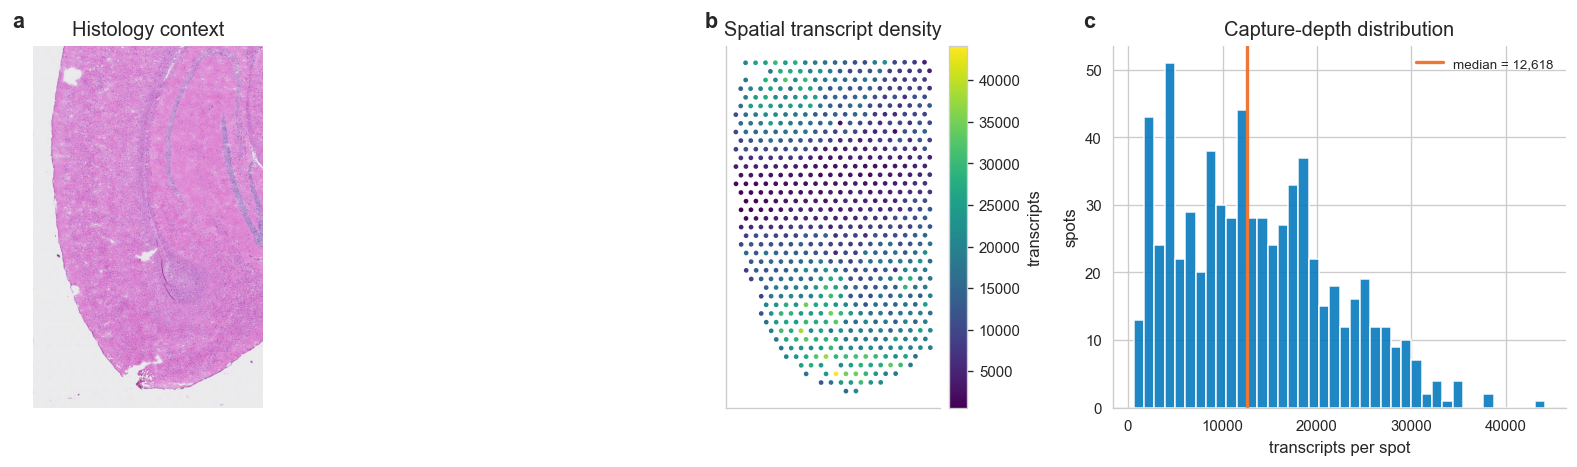

In [ ]:
def add_panel_label(ax, label):
    ax.text(
        -0.04,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom",
        ha="right",
    )


def plot_spatial_points(adata, values, ax, title, cmap="viridis"):
    coordinates = np.asarray(adata.obsm["spatial"])
    scatter = ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=values,
        s=8,
        cmap=cmap,
        linewidths=0,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(histology_image)
axes[0].set_title("Histology context")
axes[0].axis("off")
add_panel_label(axes[0], "a")

scatter = plot_spatial_points(
    raw_st,
    transcript_counts,
    axes[1],
    "Spatial transcript density",
)
plt.colorbar(
    scatter, ax=axes[1], fraction=0.046, pad=0.02,
    label="transcripts",
)
add_panel_label(axes[1], "b")

axes[2].hist(transcript_counts, bins=40, color="#0077BB", alpha=0.88)
median_count = float(np.median(transcript_counts))
axes[2].axvline(
    median_count,
    color="#EE7733",
    linewidth=2,
    label=f"median = {median_count:,.0f}",
)
axes[2].set_title("Capture-depth distribution")
axes[2].set_xlabel("transcripts per spot")
axes[2].set_ylabel("spots")
axes[2].legend(frameon=False)
add_panel_label(axes[2], "c")
plt.tight_layout()
plt.show()


### Prepared input summary

The prepared objects share the same gene axis. The spot object also
carries the virtual-cell identifiers consumed by the SR route.


In [ ]:
prepared_spatial = ad.read_h5ad(PREPARED_ST_PATH)
prepared_reference = ad.read_h5ad(PREPARED_REFERENCE_PATH)
pd.DataFrame(
    {
        "observations": [
            prepared_spatial.n_obs,
            prepared_reference.n_obs,
        ],
        "genes": [prepared_spatial.n_vars, prepared_reference.n_vars],
    },
    index=["prepared Visium", "prepared reference"],
)


In [ ]:
allocation_counts = (
    prepared_spatial.obs["estimated_cell_count"]
    .value_counts()
    .sort_index()
)
reference_fraction = (
    prepared_reference.obs["Level1"]
    .astype(str)
    .value_counts(normalize=True)
    .sort_values()
)


### Virtual-cell allocation

The panels expose the deterministic count-based rule before any
reference-guided reconstruction is interpreted.


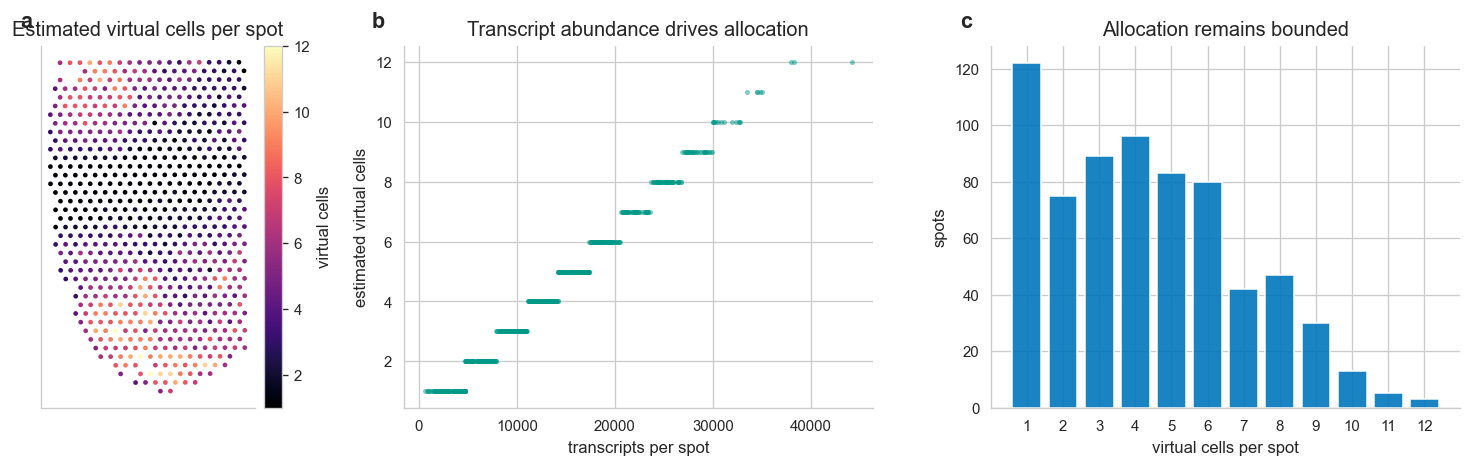

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scatter = plot_spatial_points(
    prepared_spatial,
    prepared_spatial.obs["estimated_cell_count"],
    axes[0],
    "Estimated virtual cells per spot",
    cmap="magma",
)
plt.colorbar(
    scatter, ax=axes[0], fraction=0.046, pad=0.02,
    label="virtual cells",
)
add_panel_label(axes[0], "a")

axes[1].scatter(
    prepared_spatial.obs["transcript_counts"],
    prepared_spatial.obs["estimated_cell_count"],
    s=9,
    alpha=0.5,
    color="#009988",
    linewidths=0,
)
axes[1].set_title("Transcript abundance drives allocation")
axes[1].set_xlabel("transcripts per spot")
axes[1].set_ylabel("estimated virtual cells")
add_panel_label(axes[1], "b")

axes[2].bar(
    allocation_counts.index.astype(str),
    allocation_counts.to_numpy(),
    color="#0077BB",
    alpha=0.9,
)
axes[2].set_title("Allocation remains bounded")
axes[2].set_xlabel("virtual cells per spot")
axes[2].set_ylabel("spots")
add_panel_label(axes[2], "c")
plt.tight_layout()
plt.show()


### Reference composition

This panel describes the supplied reference. It is not an estimate of
cell-type abundance in the Visium tissue.


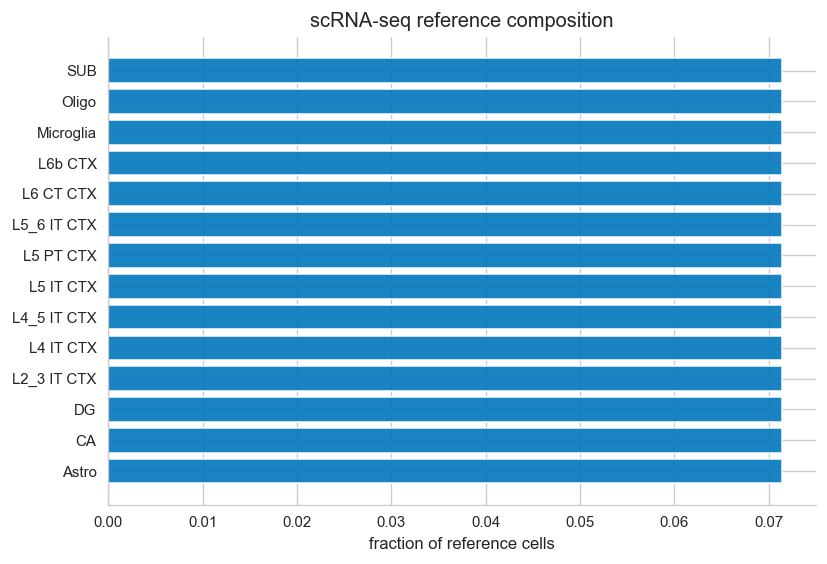

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.barh(
    reference_fraction.index,
    reference_fraction.to_numpy(),
    color="#0077BB",
    alpha=0.9,
)
ax.set_title("scRNA-seq reference composition")
ax.set_xlabel("fraction of reference cells")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. Load the formal reconstructed SVC

The published object contains reconstructed expression, source-spot
identities, spot-derived coordinates, and assigned cell types. The
notebook reads that result directly for the figures below.


In [ ]:
svc = ad.read_h5ad(SVC_PATH)
svc.obsm["spatial"] = svc.obs[["x", "y"]].to_numpy(dtype=float)
cell_type_counts = (
    svc.obs["cell_type"]
    .astype(str)
    .value_counts()
    .rename_axis("cell_type")
    .rename("virtual_cells")
)


In [ ]:
svc.obs[["cell_type", "spot_name", "x", "y"]].head()


### Reconstructed cell types in spot-derived space

Multiple virtual cells can occupy the same spot center. The spatial
panel is therefore a reconstructed allocation map, not segmentation.


In [ ]:
def plot_virtual_cells_by_type(adata, ax):
    labels = adata.obs["cell_type"].astype(str)
    palette = plt.get_cmap("tab20").colors
    for index, cell_type in enumerate(labels.value_counts().index):
        selected = labels.to_numpy() == cell_type
        ax.scatter(
            adata.obs.loc[selected, "x"],
            adata.obs.loc[selected, "y"],
            s=4,
            alpha=0.72,
            color=palette[index % len(palette)],
            label=cell_type,
            linewidths=0,
        )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("REVISE virtual cells by assigned type")
    ax.legend(
        markerscale=3,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )


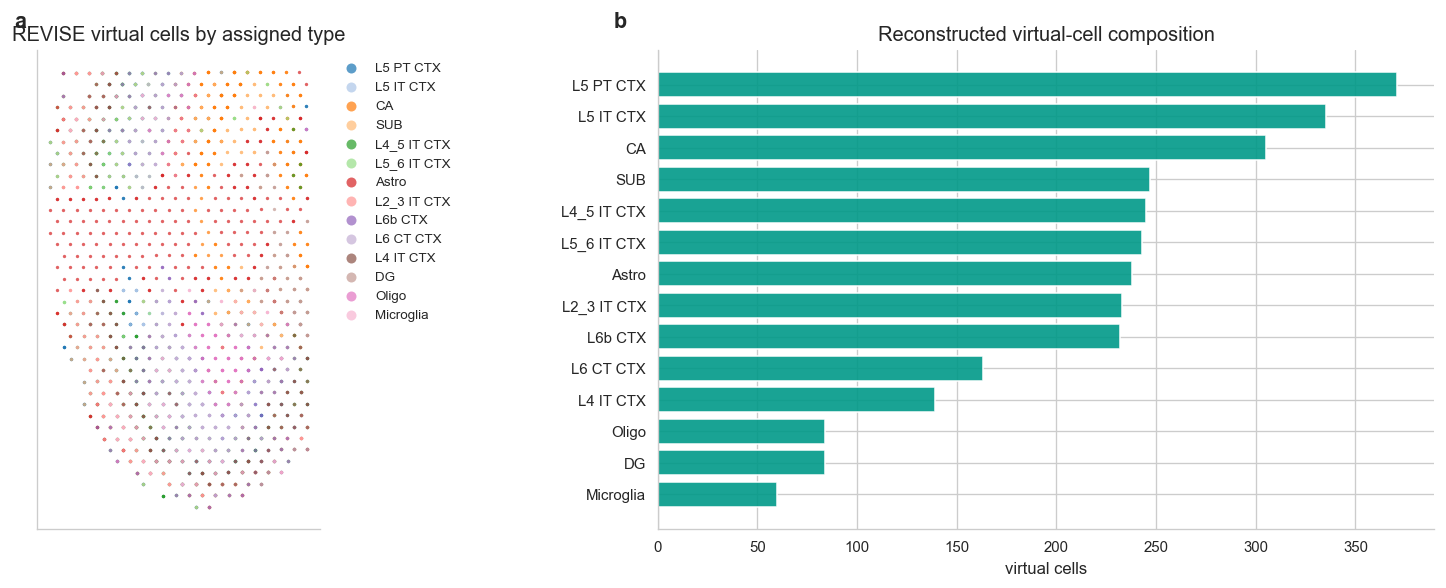

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_virtual_cells_by_type(svc, axes[0])
add_panel_label(axes[0], "a")

cell_type_counts.sort_values().plot.barh(
    ax=axes[1], color="#009988", alpha=0.9
)
axes[1].set_title("Reconstructed virtual-cell composition")
axes[1].set_xlabel("virtual cells")
axes[1].set_ylabel("")
add_panel_label(axes[1], "b")
plt.tight_layout()
plt.show()


### Representative reconstructed gene maps

The six named genes are read directly from the published expression
matrix. A missing gene fails at selection rather than being substituted.


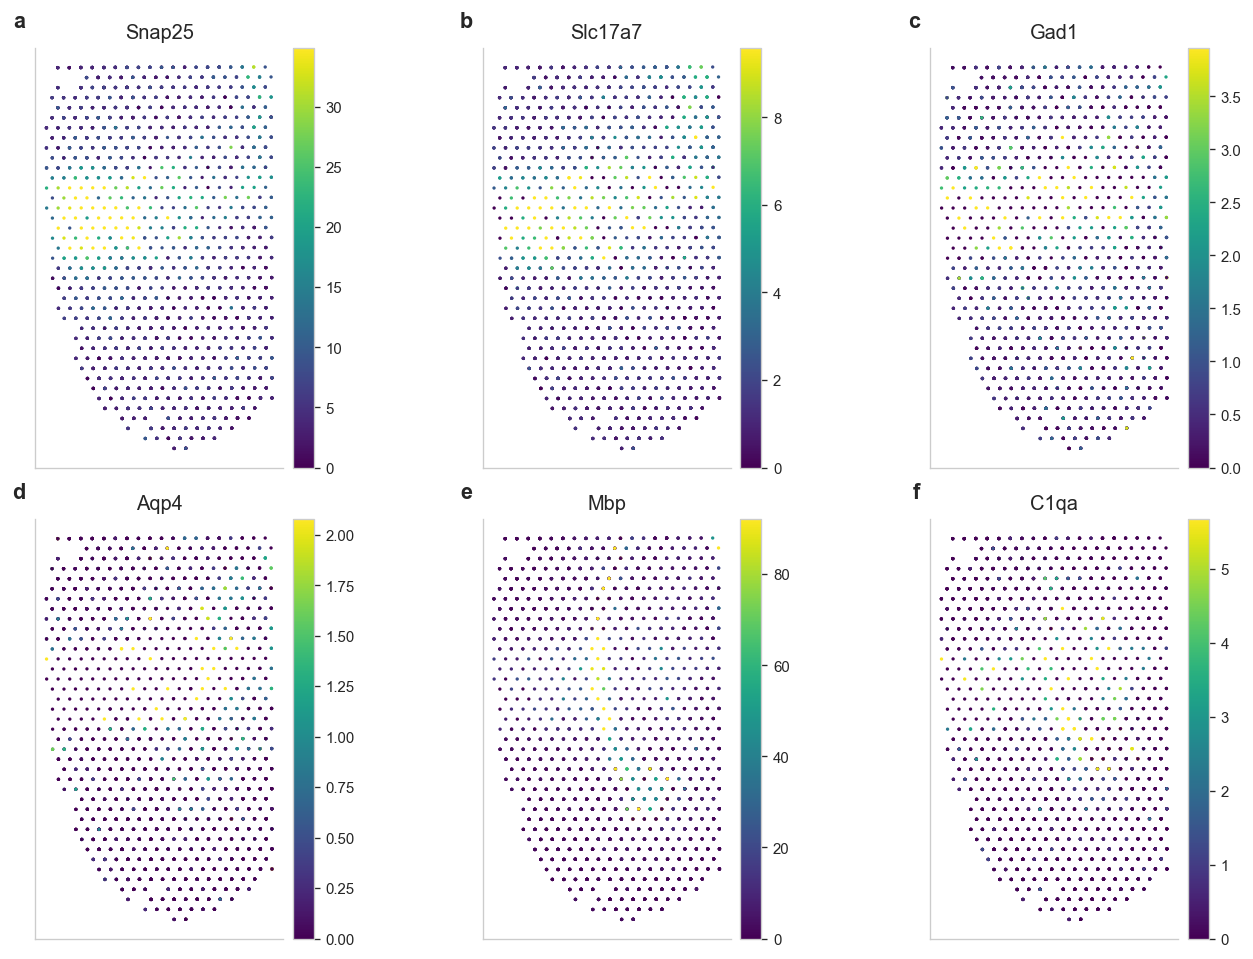

In [ ]:
def expression_vector(adata, gene):
    values = adata[:, gene].X
    if sparse.issparse(values):
        values = values.toarray()
    return np.asarray(values).ravel()


marker_genes = ["Snap25", "Slc17a7", "Gad1", "Aqp4", "Mbp", "C1qa"]
coordinates = svc.obsm["spatial"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for index, (ax, gene) in enumerate(zip(axes.ravel(), marker_genes)):
    values = expression_vector(svc, gene)
    upper = np.quantile(values, 0.99)
    scatter = ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=np.clip(values, 0, upper),
        s=4,
        cmap="viridis",
        linewidths=0,
    )
    ax.set_title(gene)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    add_panel_label(ax, chr(ord("a") + index))
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()


## Interpretation boundary

**Direct observation.** The retained images show the displayed input,
allocation, reference, spatial, and marker patterns.

**Interpretation boundary.** Virtual-cell identities and expression are
reference-guided reconstruction outputs. Shared spot centers do not imply
physical cell localization, and these figures do not establish biological
accuracy or reproduce the reconstruction in this checkout.
